# Assignment 4: Advanced VaR and Monte Carlo Option Pricing

This notebook preserves the completed solution logic and reorganizes it for
exam revision. Each question contains an English problem summary, an
independently runnable solution, Chinese line-level hints, and result guidance.

## Questions

1. Daily returns, parametric VaR, and normality testing
2. GBM terminal-price simulation
3. Risk-neutral European call pricing

## Recommended Answer Structure

1. State the financial or statistical objective.
2. Identify inputs, assumptions, and units.
3. Write the main formula or algorithm before coding.
4. Complete the code in execution order.
5. Report and interpret the result.
6. Add a short validation or reasonableness check.

## Assignment Review Checklist

- Each question can run independently.
- Imports are included in the question's own code cell.
- Random simulations use a fixed seed.
- The final answer includes interpretation, not only printed output.
- Any chart is discussed in the result Markdown.


## Question 1: VaR and Distribution Analysis

The original assignment uses WMT data. This reproducible version generates a fat-tailed return sample and applies the same required workflow.


### Structured Review

- **Hypotheses:** Write the null and alternative before selecting a test.
- **Tail choice:** Determine whether the test is one-sided or two-sided.
- **Reference distribution:** Match the statistic with the normal, Student-t, F, or chi-square distribution.
- **Decision:** Compare either the p-value with alpha or the statistic with its critical value.

### Test Selection

| Question | Typical method |
|---|---|
| One mean versus a target | One-sample t-test |
| Two independent means | Pooled or Welch t-test |
| Equality of variances | F-test or Levene test |
| First-order residual autocorrelation | Durbin-Watson |
| Predictive content of lagged variables | Granger F-test |
| Normality | Shapiro-Wilk or Anderson-Darling |

### Exam Focus

- Use `alpha/2` in each tail of a two-sided test.
- Track degrees of freedom when calling `ppf`.
- State conclusions as evidence to reject or not reject the null hypothesis.

### Common Mistakes

- Saying that a large p-value proves the null hypothesis.
- Using a one-sided critical value for a two-sided interval.
- Interpreting Granger causality as structural or philosophical causation.


In [1]:
import numpy as np
from scipy import stats

rng = np.random.default_rng(4041)
portfolio_value = 100_000
confidence = 0.99

# 用厚尾收益模拟股票价格，再由价格反算日收益率
daily_returns = 0.0004 + 0.012 * rng.standard_t(df=6, size=1000)
prices = 100 * np.cumprod(1 + daily_returns)
returns = prices[1:] / prices[:-1] - 1

z = stats.norm.ppf(confidence)
mean = returns.mean()
volatility = returns.std(ddof=1)
var_1_day = -portfolio_value * (mean - z * volatility)
var_10_day = -portfolio_value * ((1 + mean) ** 10 - 1 - z * volatility * np.sqrt(10))

skewness = stats.skew(returns, bias=False)
excess_kurtosis = stats.kurtosis(returns, fisher=True, bias=False)
shapiro = stats.shapiro(returns)

print("1-day VaR =", round(float(var_1_day), 2))
print("10-day VaR =", round(float(var_10_day), 2))
print("Skewness =", round(float(skewness), 4))
print("Excess kurtosis =", round(float(excess_kurtosis), 4))
print("Shapiro statistic =", round(float(shapiro.statistic), 6))
print("Shapiro p-value =", round(float(shapiro.pvalue), 8))
print("Normality supported =", bool(shapiro.pvalue >= 0.05))


1-day VaR = 3226.02
10-day VaR = 9851.1
Skewness = 0.0475
Excess kurtosis = 2.024
Shapiro statistic = 0.978417
Shapiro p-value = 0.0
Normality supported = False


**Result interpretation.** The normality conclusion follows the p-value, while positive VaR values are reported as loss magnitudes.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## Question 2: Monte Carlo Forecast and Call Pricing

The stock forecast uses the stated expected return mu. The option price uses a separate risk-neutral simulation with drift r.


### Structured Review

- **Purpose:** State what the code calculates and why the quantity matters in finance.
- **Inputs:** Identify the required data, parameter units, and expected data type.
- **Process:** Follow the transformation in execution order rather than reading only the final line.
- **Output:** Connect the printed value to an economic or statistical interpretation.

### Exam Focus

- Identify the lines most likely to be removed in a code-completion question.
- Trace dimensions, indices, and units through each intermediate variable.
- Use a small numerical example to check the direction and scale of the answer.

### Common Mistakes

- Reusing a variable with a different meaning.
- Depending on a previous notebook cell for an import or intermediate object.
- Reporting a number without explaining its financial meaning.


In [2]:
import numpy as np

S0, mu, sigma, T, r, strike = 50, 0.12, 0.25, 1.0, 0.05, 55
n_simulations, n_steps = 5000, 100
dt = T / n_steps
rng = np.random.default_rng(12345)
shocks = rng.standard_normal((n_simulations, n_steps))

# 真实世界路径用于价格预测
forecast_increments = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * shocks
forecast_paths = S0 * np.exp(np.cumsum(forecast_increments, axis=1))
forecast_terminal = forecast_paths[:, -1]

# 期权定价必须在风险中性世界把漂移替换为 r
pricing_increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * shocks
pricing_paths = S0 * np.exp(np.cumsum(pricing_increments, axis=1))
pricing_terminal = pricing_paths[:, -1]
payoffs = np.maximum(pricing_terminal - strike, 0)
option_price = np.exp(-r * T) * payoffs.mean()

print("Forecast terminal mean =", round(float(forecast_terminal.mean()), 4))
print("Forecast terminal median =", round(float(np.median(forecast_terminal)), 4))
print("European call price =", round(float(option_price), 4))


Forecast terminal mean = 56.615
Forecast terminal median = 54.8864
European call price = 4.1172


**Result interpretation.** Using common shocks exposes the effect of changing only the drift from mu to r for valuation.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.

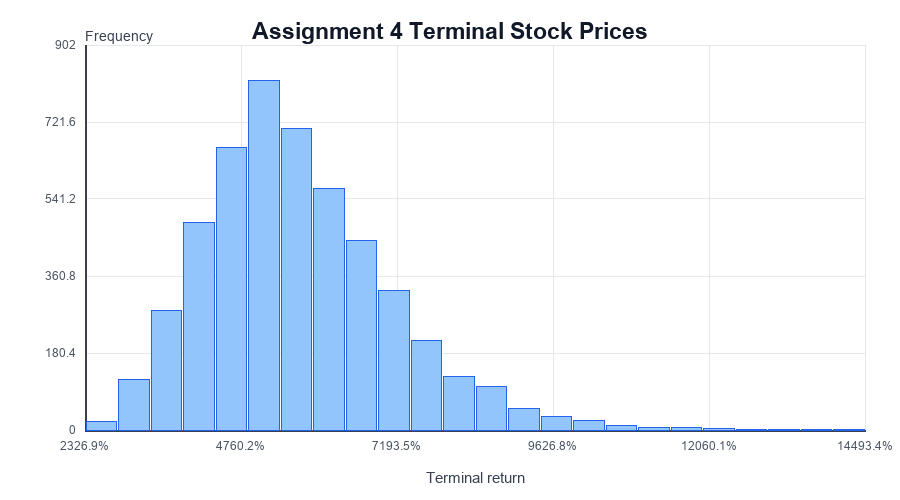
